## 📋 Overview
# This notebook demonstrates how LLM-powered translation enhances ML phishing detection
# for non-English emails by providing:
# 1. Contextually accurate translations that preserve phishing indicators
# 2. URL preservation (never translating suspicious links)
# 3. Better handling of informal/slang language than traditional translation APIs

In [1]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from langdetect import detect, LangDetectException
from dotenv import load_dotenv
from typing import Tuple
from openai import OpenAI as OR_OpenAI
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
try:
    CURRENT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    CURRENT_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))

# Load .env for OpenRouter key
env_path = os.path.join(PROJECT_ROOT, ".env")
if os.path.exists(env_path):
    load_dotenv(env_path)

OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")

if not OPENROUTER_KEY:
    print("⚠️ OPENROUTER_API_KEY missing — LLM translation will fail.")
    openrouter_client = None
else:
    openrouter_client = OR_OpenAI(
        api_key=OPENROUTER_KEY,
        base_url="https://openrouter.ai/api/v1"
    )
    print("✅ OpenRouter client configured.")

✅ OpenRouter client configured.


In [3]:
MODEL_IDS = {
    "DeepSeek": "deepseek/deepseek-chat-v3.1",
    "GPT": "openai/gpt-4.1",
    "Claude": "anthropic/claude-3.5-sonnet",
}

In [4]:
URL_REGEX = re.compile(r"https?://[^\s<>\"'\n]+")

def replace_urls_with_placeholders(text: str):
    urls = URL_REGEX.findall(text)
    placeholder_map = {}
    out = text

    for idx, url in enumerate(urls):
        ph = f"[URL_{idx}]"
        placeholder_map[ph] = url
        out = out.replace(url, ph)

    return out, placeholder_map


def restore_placeholders(text: str, placeholder_map: dict):
    for ph, url in placeholder_map.items():
        text = text.replace(ph, url)
    return text


def call_openrouter_model(prompt: str, model_id: str):
    if openrouter_client is None:
        return "❌ LLM not configured.", "error"
    try:
        resp = openrouter_client.chat.completions.create(
            model=model_id,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
            max_tokens=800,
        )
        return resp.choices[0].message.content.strip(), "ok"
    except Exception as e:
        return f"❌ OpenRouter error: {e}", "error"


def detect_and_translate(text: str, model_name: str):
    if not text or not text.strip():
        return text, "unknown", "noop"
    
    # Language detection
    try:
        detected = detect(text)
    except LangDetectException:
        detected = "unknown"
    
    # If English → no translation needed
    if detected in ("en", "unknown"):
        return text, detected, "noop"
    
    # Preserve URLs
    ph_text, ph_map = replace_urls_with_placeholders(text)
    
    # IMPROVED PROMPT - emphasizes preserving phishing signals
    prompt = f"""You are an expert cybersecurity translation specialist with deep cultural and linguistic knowledge. Your task is to translate this email to English while maintaining its full contextual meaning and preserving all phishing indicators.

    TRANSLATION REQUIREMENTS:
    
    1. **Cultural Context & Idiomatic Translation**:
       - Translate idioms, expressions, and cultural references to their natural English equivalents
       - Preserve the cultural tone and formality level appropriate to the source language
       - Maintain regional phishing tactics specific to that language/culture (e.g., tax authority names, banking terminology)
       
    2. **Intelligent Semantic Translation** (NOT word-by-word):
       - Convey the true meaning and intent behind phrases, not literal translations
       - Use natural English phrasing that a native speaker would use
       - Preserve nuanced meanings like urgency, authority, fear, or excitement
       - Translate culturally-specific concepts to their closest English equivalent
       
    3. **CRITICAL: Preserve ALL Phishing Indicators**:
       - Keep ALL urgency markers (e.g., "urgent", "immediately", "now", "verify within 24 hours")
       - Maintain suspicious phrasing (e.g., "confirm credentials", "account suspended", "claim your prize")
       - Preserve authority impersonation tactics (e.g., bank names, government agencies, delivery services)
       - Keep emotional manipulation language (fear, greed, curiosity, authority)
       - Retain any grammatical errors, typos, or awkward phrasing (these are phishing red flags)
       
    4. **Technical Preservation**:
       - DO NOT translate or remove placeholders like [URL_0], [URL_1], etc.
       - Keep all numbers, dates, and reference codes exactly as they appear
       - Preserve formatting, capitalization patterns, and punctuation
       
    5. **What NOT to Do**:
       - DO NOT summarize or paraphrase to shorten the text
       - DO NOT fix grammar, spelling, or punctuation errors
       - DO NOT make the text more formal, polite, or professional than the original
       - DO NOT remove suspicious elements or make it sound more legitimate
       - DO NOT provide explanations or notes about the translation
    
    **Example of Good Translation**:
    Original (Spanish): "Urgente tío! Tu cuenta PayPal ha sido suspendida."
    GOOD: "Urgent dude! Your PayPal account has been suspended."
    BAD: "Dear user, your PayPal account requires verification." (too formal, loses urgency)
    
    Translate the following text intelligently while strictly adhering to these guidelines:
    
    --- BEGIN TEXT ---
    {ph_text}
    --- END TEXT ---
    
    Provide ONLY the English translation with no additional commentary:"""
    
    model_id = MODEL_IDS[model_name]
    translated, status = call_openrouter_model(prompt, model_id)
    if status != "ok":
        return text, detected, "error"
    
    translated = restore_placeholders(translated, ph_map)
    return translated, detected, "ok"

In [5]:
ML_DIR = Path(PROJECT_ROOT) / "ML pipeline"

MODEL_PATH = ML_DIR / "model.pkl"
VECT_PATH = ML_DIR / "tfidf_vectorizer.pkl"

ml_model = joblib.load(MODEL_PATH)
tfidf_vectorizer = joblib.load(VECT_PATH)

print("Loaded:", type(ml_model).__name__, "/", type(tfidf_vectorizer).__name__)

Loaded: CalibratedClassifierCV / TfidfVectorizer


In [6]:
test_emails = [
    # Hungarian - WITH URL (more sophisticated phishing)
    {"body":"Kedves Ügyfelünk! Biztonsági okokból kérjük, hogy 24 órán belül ellenőrizze adatait: https://company-vpn-login-hu.com/auth?session=x7m2", "label":1},
    # Hungarian - NO URL (looks official)
    {"body":"Tisztelt Kollégák! A negyedéves pénzügyi jelentés mellékelve. Kérem szíveskedjenek áttekinteni és visszajelezni.", "label":0},
    
    # Spanish - WITH URL (lottery scam with emotional appeal)
    {"body":"¡FELICIDADES! Has sido seleccionado para recibir €50.000 del sorteo especial de Navidad. Reclama tu premio antes del viernes: https://sorteo-navidad-esp.com/premio?ref=ES9281", "label":1},
    # Spanish - NO URL (corporate communication)
    {"body":"Buenos días. Le informamos que su reunión del proyecto ha sido reagendada para el próximo martes a las 16:00 horas. Saludos cordiales.", "label":0},
    
    # French - WITH URL (sophisticated tax refund)
    {"body":"Notification officielle: Vous êtes éligible à un remboursement d'impôts de 892€. Veuillez remplir le formulaire de vérification dans les 48 heures: https://impots-gouv-remboursement.fr/formulaire?id=FR2024X8291", "label":1},
    # French - NO URL (hotel booking)
    {"body":"Bonjour, nous vous confirmons votre réservation au Grand Hôtel du 18 au 21 mars. Nous restons à votre disposition pour toute question.", "label":0},
    
    # German - WITH URL (package delivery with urgency)
    {"body":"Wichtige Mitteilung: Ihre Sendung konnte nicht zugestellt werden. Bitte aktualisieren Sie Ihre Lieferadresse innerhalb von 72 Stunden: https://dhl-zustellung-aktualisierung.de/adresse?ref=DE891234", "label":1},
    # German - NO URL (meeting update)
    {"body":"Guten Tag, Ihr Quartalsbericht-Meeting wurde auf nächsten Mittwoch um 15:00 Uhr verlegt. Bitte bestätigen Sie Ihre Teilnahme.", "label":0},
    
    # Italian - WITH URL (banking security alert)
    {"body":"Avviso di sicurezza Intesa Sanpaolo: Abbiamo rilevato attività sospette sul suo conto. Per proteggere i suoi fondi, verifichi immediatamente: https://intesa-sicurezza-online.it/verifica?token=IT82937X", "label":1},
    # Italian - NO URL (restaurant confirmation)
    {"body":"Gentile Cliente, la sua prenotazione presso il Ristorante Da Vittorio è confermata per venerdì 20:30. La ringraziamo e le auguriamo una buona serata.", "label":0},
    
    # Russian - WITH URL (customs with official tone)
    {"body":"Уважаемый получатель! Ваша посылка находится на таможенном складе. Для получения необходимо оплатить таможенный сбор до 23:59 сегодня: https://pochta-rossii-tamozhnya.ru/oplata?id=RU7382M", "label":1},
    # Russian - NO URL (flight confirmation)
    {"body":"Здравствуйте! Ваш рейс Аэрофлот SU-245 Москва-Сочи подтвержден на 28 марта в 09:30. Регистрация открывается за 2 часа до вылета.", "label":0},
    
    # Japanese - WITH URL (account suspension with politeness)
    {"body":"【重要なお知らせ】お客様のアカウントに不審なアクティビティが検出されました。アカウントの安全のため、本人確認をお願いいたします: https://rakuten-anzen-kakunin.jp/verify?user=JP82937", "label":1},
    # Japanese - NO URL (delivery notification)
    {"body":"お荷物のお届けについてご連絡いたします。ヤマト運輸より明日の午後2時から4時の間にお届け予定です。ご不在の場合は不在票を投函いたします。", "label":0},
    
    # Portuguese - WITH URL (prize with government branding)
    {"body":"Comunicado Oficial da Receita Federal: Você tem direito a restituição de R$ 3.847,00 referente ao ano fiscal 2023. Solicite já: https://receita-federal-restituicao.br/solicitar?cpf=BR82937Y", "label":1},
    # Portuguese - NO URL (flight info)
    {"body":"Prezado passageiro, confirmamos seu voo GOL G3-1234 com destino ao Rio de Janeiro na quinta-feira às 18:45. Check-in disponível 24h antes. Boa viagem!", "label":0},
    
    # Polish - WITH URL (court summons threat)
    {"body":"PILNE! Sąd Rejonowy w Warszawie: Nieopłacona grzywna w wysokości 2.500 zł. Uniknij postępowania egzekucyjnego - opłać natychmiast: https://sad-egzekucja-gov-pl.com/oplata?sprawa=PL92837W", "label":1},
    # Polish - NO URL (invoice notification)
    {"body":"Dzień dobry, Twoja faktura za zakupy w sklepie Media Markt została wystawiona i jest dostępna do pobrania w Twoim koncie. Dziękujemy za zakupy.", "label":0},
    
    # Dutch - WITH URL (energy subsidy)
    {"body":"Belangrijke mededeling Belastingdienst: U komt in aanmerking voor een energietoeslag van €1.200. Claim uw toeslag voor 31 december: https://belastingdienst-energietoeslag-nl.com/aanvraag?bsn=NL82937K", "label":1},
    # Dutch - NO URL (package delivery)
    {"body":"Geachte klant, uw pakket van Coolblue wordt morgen tussen 13:00-18:00 bezorgd. U ontvangt een sms wanneer de bezorger onderweg is. Hartelijk dank.", "label":0},
    
    # Swedish - WITH URL (pension authority)
    {"body":"Meddelande från Pensionsmyndigheten: Du har ej hämtade pensionsförmåner värda 18.400 kr. Ansök innan utgången av månaden: https://pensionsmyndigheten-utbetalning.se/ansokan?id=SE82937P", "label":1},
    # Swedish - NO URL (appointment confirmation)
    {"body":"Hej! Din bokning hos Vårdcentralen Linné är bekräftad för onsdag 10 april kl 14:30. Kom gärna 10 minuter tidigare för inskrivning. Välkommen!", "label":0},
    
    # Turkish - WITH URL (debt collection threat)
    {"body":"SON İHTAR! T.C. İcra Müdürlüğü: 8.500 TL tutarında ödenmemiş borcunuz bulunmaktadır. Yasal işlem başlatılmadan önce 48 saat içinde ödeyin: https://icra-mudurluğü-odeme.com.tr/borc?dosya=TR82937M", "label":1},
    # Turkish - NO URL (shipment update)
    {"body":"Merhaba, Hepsiburada siparişiniz kargoya verildi. Tahmini teslimat tarihi: 23 Aralık Pazartesi. Kargo takip numaranız sipariş detaylarında görülebilir.", "label":0},
    
    # Arabic - WITH URL (ministry official communication)
    {"body":"إشعار من وزارة المالية: لديك مبلغ مستحق قدره 4500 ريال كمكافأة ضريبية. يجب المطالبة خلال 5 أيام عمل: https://wizarat-maliyah-sa-gov.com/motalaba?raqm=SA82937F", "label":1},
    # Arabic - NO URL (university admission)
    {"body":"عزيزي الطالب، تم قبولك في جامعة الملك سعود لبرنامج الماجستير. يرجى مراجعة قسم القبول خلال الأسبوع القادم لإتمام إجراءات التسجيل. بالتوفيق.", "label":0},
    
    # Korean - WITH URL (national pension service)
    {"body":"국민연금공단 긴급공지: 미수령 연금급여 1,850,000원이 발생했습니다. 12월 31일까지 신청하세요: https://kookmin-yeonkeum-gongdan.kr/sinchung?beonho=KR82937N", "label":1},
    # Korean - NO URL (restaurant reservation)
    {"body":"안녕하세요, 미슐랭 레스토랑 '정식당' 예약이 12월 25일 저녁 7시로 확정되었습니다. 예약 변경은 2일 전까지 가능합니다. 감사합니다.", "label":0},
    
    # Czech - WITH URL (insurance refund)
    {"body":"Česká pojišťovna - Důležité oznámení: Máte nárok na vrácení přeplatku pojistného ve výši 5.280 Kč. Vyplňte žádost do 10 dnů: https://ceska-pojistovna-vraceni.cz/zadost?cislo=CZ82937V", "label":1},
    # Czech - NO URL (doctor appointment)
    {"body":"Dobrý den, Vaše objednání u Dr. Nováka na interním oddělení je potvrzeno na 15. ledna v 11:00. Prosím dostavte se s kartou pojištěnce. Děkujeme.", "label":0},
    
    # Greek - WITH URL (electricity company)
    {"body":"ΕΠΕΙΓΟΝ - ΔΕΗ Ανακοίνωση: Ανεξόφλητος λογαριασμός €540. Αποφύγετε διακοπή ρεύματος - πληρώστε εντός 24 ωρών: https://deh-pliromi-logariasmos.gr/pliromi?arithmos=GR82937D", "label":1},
    # Greek - NO URL (hotel reservation)
    {"body":"Αγαπητέ πελάτη, η κράτησή σας στο Hilton Athens έχει επιβεβαιωθεί για 5-8 Απριλίου. Το check-in είναι στις 15:00. Σας ευχαριστούμε!", "label":0},
    
    # Norwegian - WITH URL (road toll fine)
    {"body":"Statens vegvesen - Viktig varsel: Ubetalt bompassering på E6, gebyr 850 kr. Unngå purregebyr - betal innen fredag: https://vegvesen-bompenger-betaling.no/gebyr?id=NO82937B", "label":1},
    # Norwegian - NO URL (dentist appointment)
    {"body":"Hei! Din time hos tannlege Hansen er bekreftet til mandag 22. januar kl 09:30. Husk å møte opp 5 minutter før timen. Ha en fin dag!", "label":0},
    
    # Finnish - WITH URL (police impersonation)
    {"body":"POLIISI ILMOITUS: Henkilöllisyytesi on käytetty rikoksessa. Vahvista tietosi välittömästi identiteettivarkauden estämiseksi: https://poliisi-fi-vahvistus.com/henkilollisyys?tunnus=FI82937P", "label":1},
    # Finnish - NO URL (pharmacy order)
    {"body":"Terve! Apteekkitilauksesi on valmis noudettavaksi Yliopiston Apteekista. Noutoaika: ma-pe 8-18, la 9-15. Tilaus säilytetään viikon.", "label":0},
]

In [7]:
# Cell 6.5: Create DataFrame from test emails
df = pd.DataFrame(test_emails)
# Freeze raw_body (NEVER touched by translations)
df["raw_body"] = df["body"]
print(f"✅ Created DataFrame with {len(df)} emails")
print(f"   - Phishing (label=1): {sum(df.label == 1)}")
print(f"   - Legitimate (label=0): {sum(df.label == 0)}")
df.head()

✅ Created DataFrame with 36 emails
   - Phishing (label=1): 18
   - Legitimate (label=0): 18


,body,label,raw_body
0,"Kedves Ügyfelünk! Biztonsági okokból kérjük, h...",1,"Kedves Ügyfelünk! Biztonsági okokból kérjük, h..."
1,Tisztelt Kollégák! A negyedéves pénzügyi jelen...,0,Tisztelt Kollégák! A negyedéves pénzügyi jelen...
2,¡FELICIDADES! Has sido seleccionado para recib...,1,¡FELICIDADES! Has sido seleccionado para recib...
3,Buenos días. Le informamos que su reunión del ...,0,Buenos días. Le informamos que su reunión del ...
4,Notification officielle: Vous êtes éligible à ...,1,Notification officielle: Vous êtes éligible à ...


In [8]:
# ============================
# Timing storage
# ============================

timing = {
    "ml_only_total": 0.0,
    "ml_only_calls": 0,
    "translation": {prov: 0.0 for prov in MODEL_IDS},
    "translation_calls": {prov: 0 for prov in MODEL_IDS},
    "hybrid_ml": {prov: 0.0 for prov in MODEL_IDS},
    "hybrid_ml_calls": {prov: 0 for prov in MODEL_IDS},
}

In [9]:
# ============================================================
# 1) ML-ONLY BASELINE (NO TRANSLATION)
# ============================================================
baseline_preds = []
baseline_confs = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    body = row["raw_body"]
    start_ml = time.perf_counter()

    feat = tfidf_vectorizer.transform([body])
    pred = ml_model.predict(feat)[0]
    
    if hasattr(ml_model, "predict_proba"):
        conf = float(max(ml_model.predict_proba(feat)[0]))
    else:
        conf = 0.0
    
    elapsed_ml = time.perf_counter() - start_ml
    timing["ml_only_total"] += elapsed_ml
    timing["ml_only_calls"] += 1


    if hasattr(ml_model, "predict_proba"):
        conf = float(max(ml_model.predict_proba(feat)[0]))
    else:
        conf = 0.0

    baseline_preds.append(pred)
    baseline_confs.append(conf)

df["baseline_pred"] = baseline_preds
df["baseline_conf"] = baseline_confs

baseline_results = {
    "Accuracy": accuracy_score(df.label, df.baseline_pred),
    "Precision": precision_score(df.label, df.baseline_pred, zero_division=0),
    "Recall": recall_score(df.label, df.baseline_pred, zero_division=0),
    "F1": f1_score(df.label, df.baseline_pred, zero_division=0),
}

baseline_results

100%|██████████| 36/36 [00:00<00:00, 99.55it/s] 


{'Accuracy': 0.5833333333333334,
 'Precision': 0.56,
 'Recall': 0.7777777777777778,
 'F1': 0.6511627906976745}

In [10]:
# ============================================================
# 2) LLM TRANSLATIONS (BODY ONLY)
# ============================================================
for prov in MODEL_IDS:
    print(f"🔵 Translating bodies using {prov} ...")

    translated_list = []
    for raw in tqdm(df["raw_body"], total=len(df)):
        start_llm = time.perf_counter()

        translated, lang, status = detect_and_translate(raw, prov)
        
        elapsed_llm = time.perf_counter() - start_llm
        timing["translation"][prov] += elapsed_llm
        timing["translation_calls"][prov] += 1

        if status != "ok":
            translated_list.append(raw)
        else:
            translated_list.append(translated)

    df[f"llm_{prov}_translation"] = translated_list

df

🔵 Translating bodies using DeepSeek ...


100%|██████████| 36/36 [01:40<00:00,  2.79s/it]


🔵 Translating bodies using GPT ...


100%|██████████| 36/36 [00:35<00:00,  1.00it/s]


🔵 Translating bodies using Claude ...


100%|██████████| 36/36 [01:12<00:00,  2.00s/it]


,body,label,raw_body,baseline_pred,baseline_conf,llm_DeepSeek_translation,llm_GPT_translation,llm_Claude_translation
0,"Kedves Ügyfelünk! Biztonsági okokból kérjük, h...",1,"Kedves Ügyfelünk! Biztonsági okokból kérjük, h...",1,0.950257,"Dear Valued Customer! For security reasons, we...","Dear Customer! For security reasons, please ve...","Dear Customer! For security reasons, please ve..."
1,Tisztelt Kollégák! A negyedéves pénzügyi jelen...,0,Tisztelt Kollégák! A negyedéves pénzügyi jelen...,1,0.893779,Dear Colleagues! The quarterly financial repor...,Dear Colleagues! The quarterly financial repor...,Dear Colleagues! The quarterly financial repor...
2,¡FELICIDADES! Has sido seleccionado para recib...,1,¡FELICIDADES! Has sido seleccionado para recib...,1,0.732530,CONGRATULATIONS! You have been selected to rec...,"CONGRATS! You have been picked to get €50,000 ...",CONGRATULATIONS! You have been selected to rec...
3,Buenos días. Le informamos que su reunión del ...,0,Buenos días. Le informamos que su reunión del ...,1,0.673907,Good morning. We inform you that your project ...,Good morning. We inform you that your project ...,Good morning. We inform you that your project ...
4,Notification officielle: Vous êtes éligible à ...,1,Notification officielle: Vous êtes éligible à ...,1,0.950393,Official Notification: You are eligible for a ...,Official notification: You are eligible for a ...,Official notification: You are eligible for a ...
5,"Bonjour, nous vous confirmons votre réservatio...",0,"Bonjour, nous vous confirmons votre réservatio...",1,0.530257,"Hello, we confirm your reservation at the Gran...","Hello, we confirm your reservation at the Gran...","Hello, we confirm your reservation at the Gran..."
6,Wichtige Mitteilung: Ihre Sendung konnte nicht...,1,Wichtige Mitteilung: Ihre Sendung konnte nicht...,1,0.679778,Important Notice: Your shipment could not be d...,Important message: Your shipment could not be ...,Important Notice: Your shipment could not be d...
7,"Guten Tag, Ihr Quartalsbericht-Meeting wurde a...",0,"Guten Tag, Ihr Quartalsbericht-Meeting wurde a...",0,0.693364,"Good day, your quarterly report meeting has be...","Good day, your quarterly report meeting has be...","Hi, your quarterly report meeting has been mov..."
8,Avviso di sicurezza Intesa Sanpaolo: Abbiamo r...,1,Avviso di sicurezza Intesa Sanpaolo: Abbiamo r...,1,0.770891,Intesa Sanpaolo Security Notice: We have detec...,Intesa Sanpaolo Security Alert: We detected su...,Security Alert from Intesa Sanpaolo: We have d...
9,"Gentile Cliente, la sua prenotazione presso il...",0,"Gentile Cliente, la sua prenotazione presso il...",1,0.643040,"Dear Customer, your reservation at Ristorante ...","Dear Customer, your reservation at Ristorante ...","Dear Customer, your reservation at Da Vittorio..."


In [11]:
# ============================================================
# 3) ML on translated bodies (Hybrid)
# ============================================================
for prov in MODEL_IDS:
    preds = []
    confs = []
    col = f"llm_{prov}_translation"

    print(f"🟣 Running ML on {prov} translations...")

    for txt in df[col]:
        start_ml = time.perf_counter()

        feat = tfidf_vectorizer.transform([txt])
        pred = ml_model.predict(feat)[0]
        
        if hasattr(ml_model, "predict_proba"):
            conf = float(max(ml_model.predict_proba(feat)[0]))
        else:
            conf = 0.0
        
        elapsed_ml = time.perf_counter() - start_ml
        timing["hybrid_ml"][prov] += elapsed_ml
        timing["hybrid_ml_calls"][prov] += 1

        if hasattr(ml_model, "predict_proba"):
            conf = float(max(ml_model.predict_proba(feat)[0]))
        else:
            conf = 0.0

        preds.append(pred)
        confs.append(conf)

    df[f"ml_{prov}_pred"] = preds
    df[f"ml_{prov}_conf"] = confs

df

🟣 Running ML on DeepSeek translations...
🟣 Running ML on GPT translations...
🟣 Running ML on Claude translations...


,body,label,raw_body,baseline_pred,baseline_conf,llm_DeepSeek_translation,llm_GPT_translation,llm_Claude_translation,ml_DeepSeek_pred,ml_DeepSeek_conf,ml_GPT_pred,ml_GPT_conf,ml_Claude_pred,ml_Claude_conf
0,"Kedves Ügyfelünk! Biztonsági okokból kérjük, h...",1,"Kedves Ügyfelünk! Biztonsági okokból kérjük, h...",1,0.950257,"Dear Valued Customer! For security reasons, we...","Dear Customer! For security reasons, please ve...","Dear Customer! For security reasons, please ve...",1,0.996029,1,0.967825,1,0.979870
1,Tisztelt Kollégák! A negyedéves pénzügyi jelen...,0,Tisztelt Kollégák! A negyedéves pénzügyi jelen...,1,0.893779,Dear Colleagues! The quarterly financial repor...,Dear Colleagues! The quarterly financial repor...,Dear Colleagues! The quarterly financial repor...,0,0.995692,0,0.982632,0,0.990645
2,¡FELICIDADES! Has sido seleccionado para recib...,1,¡FELICIDADES! Has sido seleccionado para recib...,1,0.732530,CONGRATULATIONS! You have been selected to rec...,"CONGRATS! You have been picked to get €50,000 ...",CONGRATULATIONS! You have been selected to rec...,1,0.725252,1,0.870262,1,0.739830
3,Buenos días. Le informamos que su reunión del ...,0,Buenos días. Le informamos que su reunión del ...,1,0.673907,Good morning. We inform you that your project ...,Good morning. We inform you that your project ...,Good morning. We inform you that your project ...,0,0.769669,0,0.769669,0,0.769669
4,Notification officielle: Vous êtes éligible à ...,1,Notification officielle: Vous êtes éligible à ...,1,0.950393,Official Notification: You are eligible for a ...,Official notification: You are eligible for a ...,Official notification: You are eligible for a ...,1,0.828901,1,0.828901,1,0.828901
5,"Bonjour, nous vous confirmons votre réservatio...",0,"Bonjour, nous vous confirmons votre réservatio...",1,0.530257,"Hello, we confirm your reservation at the Gran...","Hello, we confirm your reservation at the Gran...","Hello, we confirm your reservation at the Gran...",0,0.842301,0,0.796225,0,0.796225
6,Wichtige Mitteilung: Ihre Sendung konnte nicht...,1,Wichtige Mitteilung: Ihre Sendung konnte nicht...,1,0.679778,Important Notice: Your shipment could not be d...,Important message: Your shipment could not be ...,Important Notice: Your shipment could not be d...,1,0.963808,1,0.977745,1,0.963808
7,"Guten Tag, Ihr Quartalsbericht-Meeting wurde a...",0,"Guten Tag, Ihr Quartalsbericht-Meeting wurde a...",0,0.693364,"Good day, your quarterly report meeting has be...","Good day, your quarterly report meeting has be...","Hi, your quarterly report meeting has been mov...",0,0.995714,0,0.995714,0,0.991684
8,Avviso di sicurezza Intesa Sanpaolo: Abbiamo r...,1,Avviso di sicurezza Intesa Sanpaolo: Abbiamo r...,1,0.770891,Intesa Sanpaolo Security Notice: We have detec...,Intesa Sanpaolo Security Alert: We detected su...,Security Alert from Intesa Sanpaolo: We have d...,1,0.990871,1,0.997564,1,0.995373
9,"Gentile Cliente, la sua prenotazione presso il...",0,"Gentile Cliente, la sua prenotazione presso il...",1,0.643040,"Dear Customer, your reservation at Ristorante ...","Dear Customer, your reservation at Ristorante ...","Dear Customer, your reservation at Da Vittorio...",0,0.583107,1,0.558559,1,0.504160


In [12]:
rows = []

rows.append({
    "Approach": "ML only (raw body)",
    **baseline_results
})

for prov in MODEL_IDS:
    rows.append({
        "Approach": f"ML + {prov}",
        "Accuracy": accuracy_score(df.label, df[f"ml_{prov}_pred"]),
        "Precision": precision_score(df.label, df[f"ml_{prov}_pred"], zero_division=0),
        "Recall": recall_score(df.label, df[f"ml_{prov}_pred"], zero_division=0),
        "F1": f1_score(df.label, df[f"ml_{prov}_pred"], zero_division=0),
    })

comp_df = pd.DataFrame(rows).set_index("Approach").round(3)
comp_df

,Accuracy,Precision,Recall,F1
Approach,,,,
ML only (raw body),0.583,0.560,0.778,0.651
ML + DeepSeek,0.750,0.800,0.667,0.727
ML + GPT,0.722,0.700,0.778,0.737
ML + Claude,0.694,0.684,0.722,0.703


✅ Graph saved to: pictures/translation_comparison.png


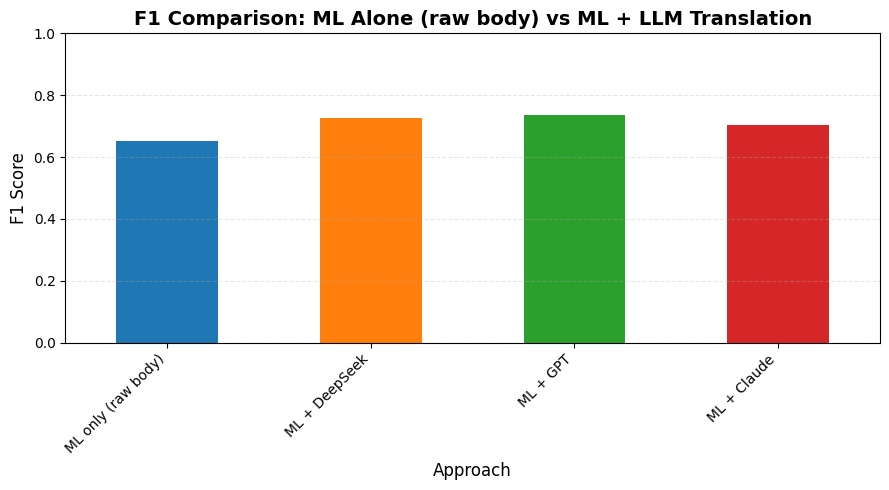

In [13]:
plt.figure(figsize=(9,5))
comp_df["F1"].plot(kind="bar", color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title("F1 Comparison: ML Alone (raw body) vs ML + LLM Translation", fontsize=14, fontweight='bold')
plt.ylabel("F1 Score", fontsize=12)
plt.xlabel("Approach", fontsize=12)
plt.ylim(0,1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# Save the graph
plt.savefig(os.path.join(PROJECT_ROOT, "pictures", "translation_comparison.png"), dpi=300, bbox_inches='tight')
print("✅ Graph saved to: pictures/translation_comparison.png")

plt.show()

In [14]:
print("\n" + "="*70)
print("⏱️ LATENCY ANALYSIS: ML ONLY vs HYBRID ML + LLM TRANSLATION")
print("="*70)

rows = []

# ML-only
avg_ml_only = timing["ml_only_total"] / timing["ml_only_calls"]
rows.append({
    "Approach": "ML only",
    "Avg ML Time (ms)": avg_ml_only * 1000,
    "Total Time (sec)": timing["ml_only_total"]
})

print(f"\nML ONLY:")
print(f"  Avg inference time: {avg_ml_only*1000:.2f} ms")

# Hybrid
for prov in MODEL_IDS:
    avg_trans = timing["translation"][prov] / timing["translation_calls"][prov]
    avg_hybrid_ml = timing["hybrid_ml"][prov] / timing["hybrid_ml_calls"][prov]
    total_avg = avg_trans + avg_hybrid_ml

    rows.append({
        "Approach": f"ML + {prov}",
        "Avg Translation Time (ms)": avg_trans * 1000,
        "Avg ML Time (ms)": avg_hybrid_ml * 1000,
        "Avg Total Time (ms)": total_avg * 1000
    })

    print(f"\nML + {prov}:")
    print(f"  Avg translation time: {avg_trans*1000:.0f} ms")
    print(f"  Avg ML time:          {avg_hybrid_ml*1000:.2f} ms")
    print(f"  Avg total per email:  {total_avg:.2f} sec")

timing_df = pd.DataFrame(rows).set_index("Approach")
timing_df


⏱️ LATENCY ANALYSIS: ML ONLY vs HYBRID ML + LLM TRANSLATION

ML ONLY:
  Avg inference time: 6.75 ms

ML + DeepSeek:
  Avg translation time: 2784 ms
  Avg ML time:          7.71 ms
  Avg total per email:  2.79 sec

ML + GPT:
  Avg translation time: 995 ms
  Avg ML time:          7.77 ms
  Avg total per email:  1.00 sec

ML + Claude:
  Avg translation time: 2003 ms
  Avg ML time:          9.19 ms
  Avg total per email:  2.01 sec


,Avg ML Time (ms),Total Time (sec),Avg Translation Time (ms),Avg Total Time (ms)
Approach,,,,
ML only,6.750225,0.243008,NaN,NaN
ML + DeepSeek,7.709939,NaN,2783.911453,2791.621392
ML + GPT,7.773411,NaN,994.594069,1002.367481
ML + Claude,9.186772,NaN,2003.188650,2012.375422
